In [11]:
#SECTION 0

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity

In [12]:
#0 Import Dataset

df=pd.read_csv("all_essays_sentences_only.csv")

In [13]:
# Displaying Data

df=df.drop(columns=["Unnamed: 1"])
df=df.drop(columns=["Unnamed: 2"])
df=df.drop(columns=["Unnamed: 3"])
df=df.drop(columns=["Unnamed: 4"])

rows, cols=df.shape
print(df.head())

print("Rows:", rows)
print("Columns:", cols)


                                            sentence
0  Can one abandon human nature and remain morall...
1  In Macbeth, Shakespeare initially depicts Lady...
2  She embraces the devilish nature of the evil s...
3  She then demands to not let “heaven peep” from...
4  Although Lady Macbeth had seemingly no qualms ...
Rows: 1067
Columns: 1


In [14]:
#0 Cleaned Text

df["cleaned_text"]=df["sentence"].str.lower()
df[["cleaned_text"]].head()

,cleaned_text
0,can one abandon human nature and remain morall...
1,"in macbeth, shakespeare initially depicts lady..."
2,she embraces the devilish nature of the evil s...
3,she then demands to not let “heaven peep” from...
4,although lady macbeth had seemingly no qualms ...


In [15]:
# 2: REBUILD TFIDF 
vectorizer = TfidfVectorizer(stop_words='english', max_features=500)
tfidf_matrix = vectorizer.fit_transform(df['cleaned_text'])
feature_names = vectorizer.get_feature_names_out()
print("TF-IDF matrix shape:", tfidf_matrix.shape)


TF-IDF matrix shape: (1067, 500)


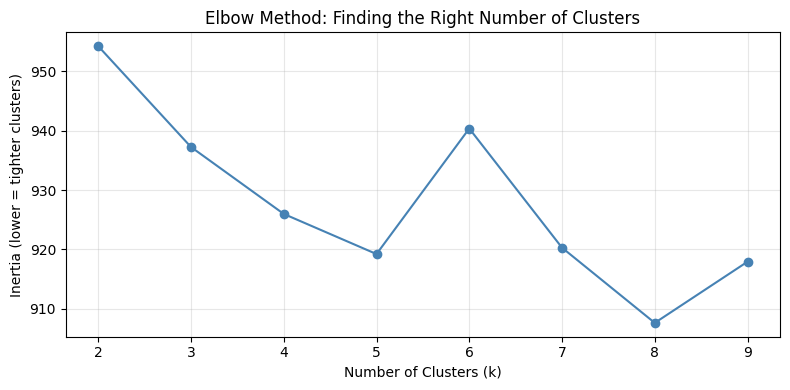

Look for the elbow — where the curve bends and flattens.
That k value is usually a good choice.



In [26]:

# SECTION 1: ELBOW METHOD — find the right number of clusters

inertia_scores = []
cluster_range = range(2, 10)

for k in cluster_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=3)
    model.fit(tfidf_matrix)
    inertia_scores.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(cluster_range, inertia_scores, marker='o', color='steelblue')
plt.title('Elbow Method: Finding the Right Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (lower = tighter clusters)')
plt.xticks(cluster_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("Look for the elbow — where the curve bends and flattens.")
print("That k value is usually a good choice.\n")

In [48]:

# SECTION 2: RUN K-MEANS with your chosen number of clusters

NUM_CLUSTERS = 5  # change this after looking at the elbow plot

kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
kmeans.fit(tfidf_matrix)
df['cluster'] = kmeans.labels_


In [49]:

# SECTION 3: TOP WORDS PER CLUSTER

print("=" * 50)
print("TOP WORDS PER CLUSTER")
print("=" * 50)

names=['Macbeths Torment', 'Friend Drama', 'Summer Applications', 'Math Passion', 'Old School Essay', 'Character Fight']

for cluster_num in range(NUM_CLUSTERS):
    center = kmeans.cluster_centers_[cluster_num]
    top_word_indices = center.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_word_indices]
    doc_count = (df['cluster'] == cluster_num).sum()
    print(f"\nCluster {cluster_num} ({doc_count} documents)")
    print(f"Top words: {', '.join(top_words)}")
    print(names[cluster_num])
    print("-" * 40)


TOP WORDS PER CLUSTER

Cluster 0 (69 documents)
Top words: alab, thiago, boy, bitch, right, leave, didn, seriously, did, started
Macbeths Torment
----------------------------------------

Cluster 1 (821 documents)
Top words: want, problem, math, love, just, like, time, way, work, school
Friend Drama
----------------------------------------

Cluster 2 (85 documents)
Top words: thiago, just, wasn, right, wanted, couldn, heavy, worst, alimez, bit
Summer Applications
----------------------------------------

Cluster 3 (63 documents)
Top words: dvir, thiago, alab, bit, better, head, did, face, just, oh
Math Passion
----------------------------------------

Cluster 4 (29 documents)
Top words: know, didn, don, alab, thiago, struggle, challenges, pure, think, dvir
Old School Essay
----------------------------------------


In [50]:

# SECTION 4: CLUSTER METRICS

sil = silhouette_score(tfidf_matrix, df['cluster'])
db = davies_bouldin_score(tfidf_matrix.toarray(), df['cluster'])

print("\n" + "=" * 50)
print("CLUSTER QUALITY METRICS")
print("=" * 50)
print(f"\nSilhouette Score: {sil:.3f}")
print("  > 0.5 = strong clusters")
print("  0.2-0.5 = reasonable clusters")
print("  < 0.2 = weak or overlapping clusters")
print(f"\nDavies-Bouldin Score: {db:.3f}")
print("  Closer to 0 = better separated clusters")
print(f"\nDocuments per cluster:")
print(df['cluster'].value_counts().sort_index())
print("If one cluster has 90% of documents, try a different k\n")


CLUSTER QUALITY METRICS

Silhouette Score: 0.046
  > 0.5 = strong clusters
  0.2-0.5 = reasonable clusters
  < 0.2 = weak or overlapping clusters

Davies-Bouldin Score: 3.750
  Closer to 0 = better separated clusters

Documents per cluster:
cluster
0     69
1    821
2     85
3     63
4     29
Name: count, dtype: int64
If one cluster has 90% of documents, try a different k



In [51]:

# SECTION 5: SAMPLE DOCUMENTS FROM EACH CLUSTER

print("=" * 50)
print("SAMPLE DOCUMENTS FROM EACH CLUSTER")
print("=" * 50)

for cluster_num in range(NUM_CLUSTERS):
    print(f"\n--- Cluster {cluster_num} ---")
    samples = df[df['cluster'] == cluster_num]['cleaned_text'].head(3)
    for i, text in enumerate(samples, 1):
        print(f"  [{i}] {text[:200]}...")

SAMPLE DOCUMENTS FROM EACH CLUSTER

--- Cluster 0 ---
  [1] alab....
  [2] alab, in the flesh....
  [3] alab was a sniveling, shivering mess…they must have been wandering for quite a while....

--- Cluster 1 ---
  [1] can one abandon human nature and remain morally undisturbed at the same time (prepositional phrase), or are the two intrinsically bound?...
  [2] in macbeth, shakespeare initially depicts lady macbeth as a heartless, ambitious woman who would execute anything to satisfy her greed for power and prestige, including plotting with her husband macbe...
  [3] she embraces the devilish nature of the evil sources in order to achieve her darkest desires, openly urges the spirits to “unsex” her and fill her with the “direst cruelty,” stripping herself from her...

--- Cluster 2 ---
  [1] thiago cursed to himself as he trudged through the heavy snow....
  [2] thiago, being the brazilian beach boy he is, longingly wished for a hot summer as he zipped his jacket higher....
  [3] never

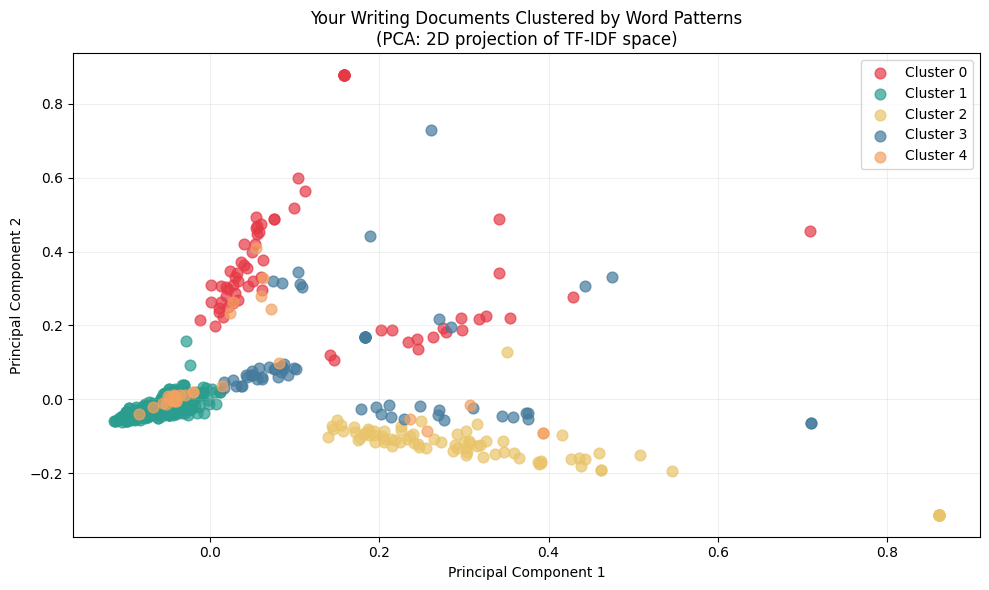

Each dot = one document. Dots close together = similar word patterns.



In [52]:

# SECTION 6: PCA SCATTER PLOT — visualize clusters in 2D

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())

plot_df = pd.DataFrame({
    'x': coords[:, 0],
    'y': coords[:, 1],
    'cluster': df['cluster'].astype(str)
})

colors = ['#e63946', '#2a9d8f', '#e9c46a', '#457b9d', '#f4a261']

plt.figure(figsize=(10, 6))
for cluster_num in range(NUM_CLUSTERS):
    subset = plot_df[plot_df['cluster'] == str(cluster_num)]
    plt.scatter(subset['x'], subset['y'],
                label=f'Cluster {cluster_num}',
                alpha=0.7, s=60, color=colors[cluster_num])

plt.title('Your Writing Documents Clustered by Word Patterns\n(PCA: 2D projection of TF-IDF space)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
print("Each dot = one document. Dots close together = similar word patterns.\n")

In [53]:

# SECTION 7: BUILD COSINE SIMILARITY MATRIX

similarity_matrix = cosine_similarity(tfidf_matrix)
print("Similarity matrix shape:", similarity_matrix.shape)
print(f"\nSample (first 4 documents vs first 4):")
print(np.round(similarity_matrix[:4, :4], 3))
print("Diagonal is always 1.0 — every document is identical to itself\n")


Similarity matrix shape: (1067, 1067)

Sample (first 4 documents vs first 4):
[[1.    0.    0.227 0.   ]
 [0.    1.    0.083 0.   ]
 [0.227 0.083 1.    0.   ]
 [0.    0.    0.    1.   ]]
Diagonal is always 1.0 — every document is identical to itself



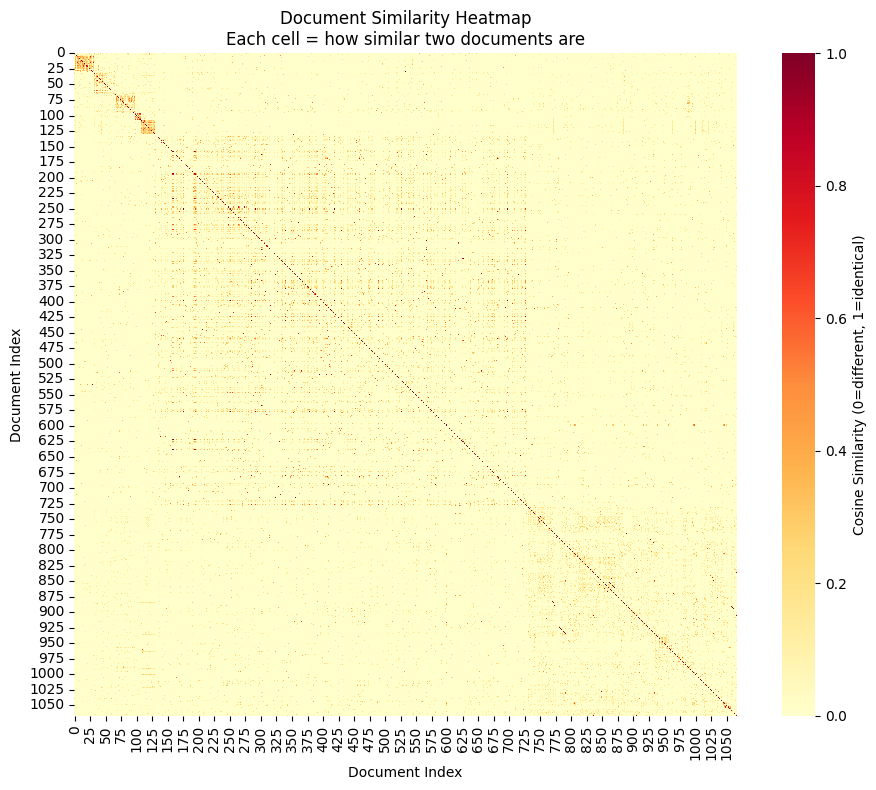

Bright red = very similar. Pale yellow = very different.



In [54]:

# SECTION 8: SIMILARITY HEATMAP

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, cmap='YlOrRd', vmin=0, vmax=1,
            square=True,
            cbar_kws={'label': 'Cosine Similarity (0=different, 1=identical)'})
plt.title('Document Similarity Heatmap\nEach cell = how similar two documents are')
plt.xlabel('Document Index')
plt.ylabel('Document Index')
plt.tight_layout()
plt.show()
print("Bright red = very similar. Pale yellow = very different.\n")


In [60]:

# SECTION 9: MOST AND LEAST SIMILAR DOCUMENT PAIRS

sim_no_diagonal = similarity_matrix.copy()
np.fill_diagonal(sim_no_diagonal, 0)

most_similar_idx = np.unravel_index(np.argmax(sim_no_diagonal), sim_no_diagonal.shape)
doc_a, doc_b = most_similar_idx

sim_find_low = similarity_matrix.copy()
np.fill_diagonal(sim_find_low, 1)
least_similar_idx = np.unravel_index(np.argmin(sim_find_low), sim_find_low.shape)
doc_c, doc_d = least_similar_idx

print("=" * 50)
print("YOUR MOST SIMILAR DOCUMENT PAIR")
print("=" * 50)
print(f"Score: {similarity_matrix[doc_a][doc_b]:.3f}")
print(f"\nDocument {doc_a}:\n  {df['cleaned_text'].iloc[doc_a][:300]}...")
print(f"\nDocument {doc_b}:\n  {df['cleaned_text'].iloc[doc_b][:300]}...")
print("\nQuestion: why do you think these two are so similar?\n")
print("\nAnswer: I think they are so similar because they both share words that are considered 'important' / have more weight than regular commmon words. In my previous analysis, Thiago and Dvir both have a lot of importance attached to them, probably because they are btoh unique and relatively prevalent as well.\n")

print("=" * 50)
print("YOUR LEAST SIMILAR DOCUMENT PAIR")
print("=" * 50)
print(f"Score: {similarity_matrix[doc_c][doc_d]:.3f}")
print(f"\nDocument {doc_c}:\n  {df['cleaned_text'].iloc[doc_c][:300]}...")
print(f"\nDocument {doc_d}:\n  {df['cleaned_text'].iloc[doc_d][:300]}...")
print("\nQuestion: what makes these two so different?\n")
print("\nAnswer: I think they are so different because even though they are actually from the same essay, they do not share words that are considered 'important' / have more weight than regular commmon words. However, I find it actually very surprising that this is my least similar document pair.\n")

YOUR MOST SIMILAR DOCUMENT PAIR
Score: 1.000

Document 424:
  thiago admitted that ever since they officially met, he had never heard dvir laugh even to as much crack a smile....

Document 726:
  thiago bent down to pat dvir’s back, “hey.”...

Question: why do you think these two are so similar?


Answer: I think they are so similar because they both share words that are considered 'important' / have more weight than regular commmon words. In my previous analysis, Thiago and Dvir both have a lot of importance attached to them, probably because they are btoh unique and relatively prevalent as well.

YOUR LEAST SIMILAR DOCUMENT PAIR
Score: 0.000

Document 0:
  can one abandon human nature and remain morally undisturbed at the same time (prepositional phrase), or are the two intrinsically bound?...

Document 1:
  in macbeth, shakespeare initially depicts lady macbeth as a heartless, ambitious woman who would execute anything to satisfy her greed for power and prestige, including plotting 

In [63]:

# SECTION 10: FIND MOST SIMILAR DOCUMENTS TO A GIVEN DOCUMENT

def find_most_similar(doc_index, similarity_matrix, df, top_n=5):
    scores = similarity_matrix[doc_index]
    sorted_indices = scores.argsort()[::-1]
    similar_indices = [i for i in sorted_indices if i != doc_index][:top_n]

    print(f"Source document [{doc_index}]:")
    print(f"  {df['cleaned_text'].iloc[doc_index][:250]}...\n")
    print(f"Top {top_n} most similar documents:\n")

    for rank, idx in enumerate(similar_indices, 1):
        print(f"  [{rank}] Similarity: {scores[idx]:.3f}")
        print(f"       {df['cleaned_text'].iloc[idx][:200]}...")
        print()

find_most_similar(doc_index=1, similarity_matrix=similarity_matrix, df=df)

Source document [1]:
  in macbeth, shakespeare initially depicts lady macbeth as a heartless, ambitious woman who would execute anything to satisfy her greed for power and prestige, including plotting with her husband macbeth to kill the king duncan and overtake the throne...

Top 5 most similar documents:

  [1] Similarity: 0.644
       following the murder of duncan, when lady macbeth ridicules macbeth for fearing a “painted devil,” (gerund phrase) she downplays the horrifying reality of hell by diminishing it as a harmless image (2...

  [2] Similarity: 0.487
       this understatement not only highlights lady macbeth’s scorn of macbeth’s cowardice and weak-mindedness, but it also indirectly emphasizes how she attempts to suppress any acknowledgment of divine con...

  [3] Similarity: 0.457
       when lady macbeth rubs her hands while sleep-walking, exclaiming, “out, damned spot, out,” her compulsive gesture and fractured speech suggest that her shame of unlawfully planning duncan’

In [75]:

# SECTION 11: SEARCH YOUR OWN WRITING WITH A NEW QUERY

def search_my_writing(query_text, vectorizer, tfidf_matrix, df, top_n=5):
    # transform() uses the existing vocabulary — NOT fit_transform()
    # fit_transform() would learn a new vocabulary from your query alone
    query_vector = vectorizer.transform([query_text])
    query_similarities = cosine_similarity(query_vector, tfidf_matrix)[0]
    top_indices = query_similarities.argsort()[::-1][:top_n]

    print(f"Query: '{query_text}'")
    print(f"\nMost similar passages in your writing:\n")

    for rank, idx in enumerate(top_indices, 1):
        score = query_similarities[idx]
        if score == 0:
            print(f"  [{rank}] No similarity found (score: 0.000)")
            print(f"       This word may not be in your writing vocabulary")
        else:
            print(f"  [{rank}] Similarity: {score:.3f}")
            print(f"       {df['cleaned_text'].iloc[idx][:250]}...")
        print()

# Change this query to anything you want to search for in your writing
search_my_writing(
    query_text="Macbeth",
    vectorizer=vectorizer,
    tfidf_matrix=tfidf_matrix,
    df=df
)

Query: 'Macbeth'

Most similar passages in your writing:

  [1] Similarity: 0.687
       in macbeth, shakespeare initially depicts lady macbeth as a heartless, ambitious woman who would execute anything to satisfy her greed for power and prestige, including plotting with her husband macbeth to kill the king duncan and overtake the throne...

  [2] Similarity: 0.649
       following the murder of duncan, when lady macbeth ridicules macbeth for fearing a “painted devil,” (gerund phrase) she downplays the horrifying reality of hell by diminishing it as a harmless image (2.2.71)....

  [3] Similarity: 0.605
       this understatement not only highlights lady macbeth’s scorn of macbeth’s cowardice and weak-mindedness, but it also indirectly emphasizes how she attempts to suppress any acknowledgment of divine consequences by frivolously devaluing it....

  [4] Similarity: 0.545
       since lady macbeth had repeatedly scolded macbeth for being burdened by compromised morals, the irony of her

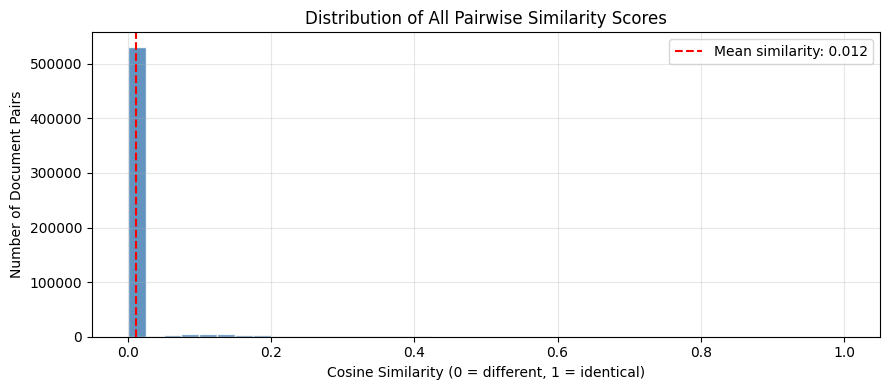

Average similarity across all pairs: 0.012
Most similar pair:  1.000
Least similar pair: 0.000

Reflection questions:
  - Is your writing more similar overall, or more varied?
  - Does this match your own sense of how diverse your topics are?
  - Which pair surprised you most?


In [76]:

# SECTION 12: DISTRIBUTION OF ALL PAIRWISE SIMILARITY SCORES

upper_triangle_indices = np.triu_indices_from(similarity_matrix, k=1)
all_pair_scores = similarity_matrix[upper_triangle_indices]

plt.figure(figsize=(9, 4))
plt.hist(all_pair_scores, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(np.mean(all_pair_scores), color='red', linestyle='--',
            label=f'Mean similarity: {np.mean(all_pair_scores):.3f}')
plt.title('Distribution of All Pairwise Similarity Scores')
plt.xlabel('Cosine Similarity (0 = different, 1 = identical)')
plt.ylabel('Number of Document Pairs')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average similarity across all pairs: {np.mean(all_pair_scores):.3f}")
print(f"Most similar pair:  {np.max(all_pair_scores):.3f}")
print(f"Least similar pair: {np.min(all_pair_scores):.3f}")
print()
print("Reflection questions:")
print("  - Is your writing more similar overall, or more varied?")
print("  - Does this match your own sense of how diverse your topics are?")
print("  - Which pair surprised you most?")

### 12. Reflection Questions

-- My writing is by far more similar overall, with very very little variance

-- It relatively makes sense because the topics I wrote about in the document were quite different from each other. For example, there were creative fictional stories, personal applications answers for summer camps, and highly analytical essays with diffferent themes. 

-- I'm surprised one of my least similar pairs was document 0 and 1 because they are both part of the same essay and one follows the other.